In [ ]:
!python -m spacy download pt_core_news_sm
!pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 49.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Hugging Face Transformers (modelos específicos para PT-BR)

A plataforma Hugging Face oferece uma grande variedade de modelos pré-treinados em português, como BERTimbau, DistilBERT, e GPT-2 adaptados para o português. Eles podem ser usados para diversas tarefas como análise de sentimentos, classificação de texto, geração de texto e sumarização.

### Primeiros passos na plataforma
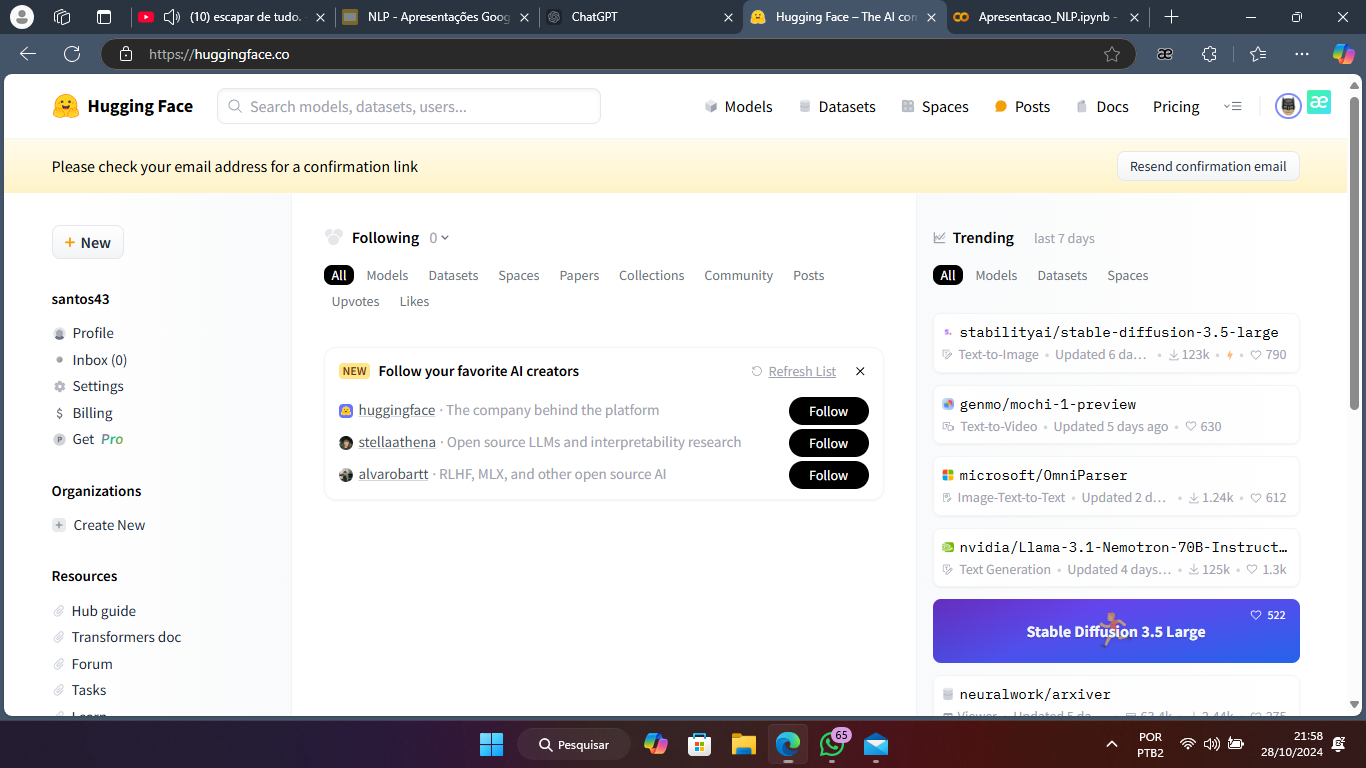

### POS tagging implementação

In [ ]:
import spacy
from spacy.lang.pt.examples import sentences


nlp = spacy.load("pt_core_news_sm")
doc = nlp(sentences[0])
print(doc.text)

Apple está querendo comprar uma startup do Reino Unido por 100 milhões de dólares


## Tags\Siginificados


| Palavra  | Tag   | Significado                |
|----------|-------|----------------------------|
| Apple    | PROPN | Nome próprio               |
| está     | AUX   | Verbo auxiliar             |
| querendo | VERB  | Verbo                      |
| comprar  | VERB  | Verbo                      |
| uma      | DET   | Determinante               |
| startup  | NOUN  | Substantivo                |
| do       | ADP   | Preposição                 |
| Reino    | PROPN | Nome próprio               |
| Unido    | PROPN | Nome próprio               |
| por      | ADP   | Preposição                 |
| 100      | NUM   | Número                     |
| milhões  | NUM   | Número                     |
| de       | ADP   | Preposição                 |
| dólares  | NOUN  | Substantivo                |


In [ ]:
for token in doc:
  print(token.text, token.pos_)

Apple PROPN
está AUX
querendo VERB
comprar VERB
uma DET
startup NOUN
do ADP
Reino PROPN
Unido PROPN
por ADP
100 NUM
milhões NUM
de ADP
dólares NOUN


In [ ]:
!pip install language_tool_python

In [ ]:
# Importar bibliotecas necessárias
import nltk
import spacy
import language_tool_python
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from tabulate import tabulate

nltk.download('stopwords')
nltk.download('rslp')
tool = language_tool_python.LanguageTool('pt-BR')
texto_com_erros = "Eu está aprendendo a programar em Python. O gatos correm rapidamente."

# Corrigir o texto
matches = tool.check(texto_com_erros)
texto_corrigido = language_tool_python.utils.correct(texto_com_erros, matches)
print("Texto corrigido:")
print(texto_corrigido)
print("\n")

# Carregar modelo de linguagem do spaCy para Português
nlp = spacy.load('pt_core_news_sm')

# Tokenizar o texto
doc = nlp(texto_corrigido)

# Remover stop words
stop_words = set(stopwords.words('portuguese'))
tokens_sem_stopwords = [
    token for token in doc
    if not token.is_stop and not token.is_punct and token.text.lower() not in stop_words
]


stemmer = RSLPStemmer()

# Preparar dados para a tabela
dados = []
for token in tokens_sem_stopwords:
    token_texto = token.text
    token_stem = stemmer.stem(token_texto)
    token_lemma = token.lemma_
    dados.append([token_texto, token_stem, token_lemma])

# Exibir a tabela
print("Tabela de Tokens, Stem e Lematização:")
print(tabulate(dados, headers=['Token', 'Stem', 'Lematização']))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.
INFO:language_tool_python.download_lt:Unzipping /tmp/tmpegvk5bcf.zip to /root/.cache/language_tool_python.
INFO:language_tool_python.download_lt:Downloaded https://www.languagetool.org/download/LanguageTool-6.4.zip to /root/.cache/language_tool_python.


Texto corrigido:
Eu estou aprendendo a programar em Python. O gato correm rapidamente.


Tabela de Tokens, Stem e Lematização:
Token        Stem     Lematização
-----------  -------  -------------
aprendendo   aprend   aprender
programar    program  programar
Python       python   Python
gato         gat      gato
correm       corr     correr
rapidamente  rapid    rapidamente
